There exist n rectangles in a 2D plane with edges parallel to the x and y axis. You are given two 2D integer arrays bottomLeft and topRight where bottomLeft[i] = [a_i, b_i] and topRight[i] = [c_i, d_i] represent the bottom-left and top-right coordinates of the ith rectangle, respectively.

You need to find the maximum area of a square that can fit inside the intersecting region of at least two rectangles. Return 0 if such a square does not exist.

 

Example 1:

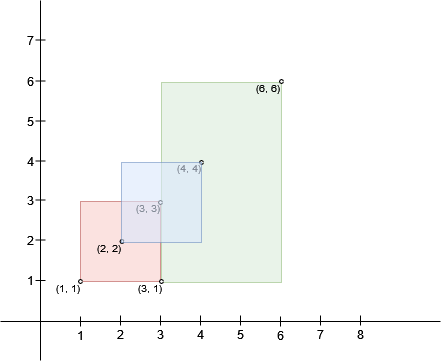

Input: bottomLeft = [[1,1],[2,2],[3,1]], topRight = [[3,3],[4,4],[6,6]]

Output: 1

Explanation:

A square with side length 1 can fit inside either the intersecting region of rectangles 0 and 1 or the intersecting region of rectangles 1 and 2. Hence the maximum area is 1. It can be shown that a square with a greater side length can not fit inside any intersecting region of two rectangles.

Example 2:

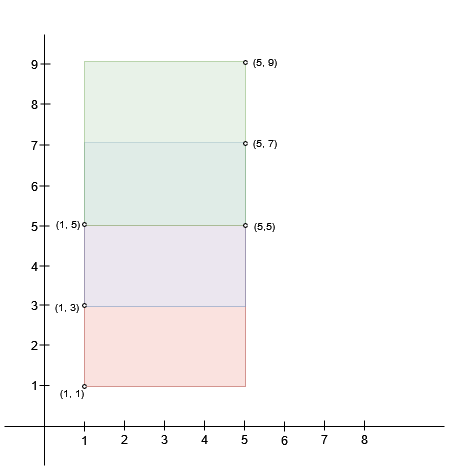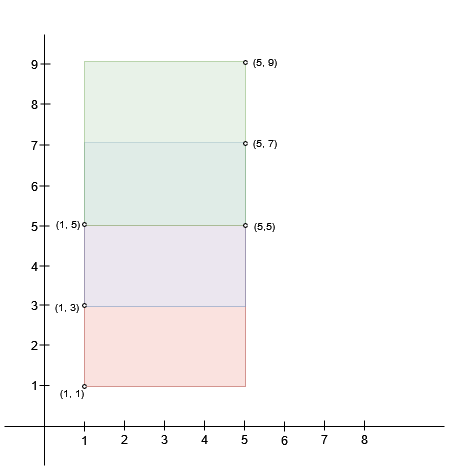

Input: bottomLeft = [[1,1],[1,3],[1,5]], topRight = [[5,5],[5,7],[5,9]]

Output: 4

Explanation:

A square with side length 2 can fit inside either the intersecting region of rectangles 0 and 1 or the intersecting region of rectangles 1 and 2. Hence the maximum area is 2 * 2 = 4. It can be shown that a square with a greater side length can not fit inside any intersecting region of two rectangles.

Example 3:
  

Input: bottomLeft = [[1,1],[2,2],[1,2]], topRight = [[3,3],[4,4],[3,4]]

Output: 1

Explanation:

A square with side length 1 can fit inside the intersecting region of any two rectangles. Also, no larger square can, so the maximum area is 1. Note that the region can be formed by the intersection of more than 2 rectangles.

Example 4:
  

Input: bottomLeft = [[1,1],[3,3],[3,1]], topRight = [[2,2],[4,4],[4,2]]

Output: 0

Explanation:

No pair of rectangles intersect, hence, the answer is 0.

 

Constraints:

    n == bottomLeft.length == topRight.length
    2 <= n <= 103
    bottomLeft[i].length == topRight[i].length == 2
    1 <= bottomLeft[i][0], bottomLeft[i][1] <= 107
    1 <= topRight[i][0], topRight[i][1] <= 107
    bottomLeft[i][0] < topRight[i][0]
    bottomLeft[i][1] < topRight[i][1]

 

In [ ]:
class Solution:
    def largestSquareArea(self, bottomLeft: List[List[int]], topRight: List[List[int]]) -> int:
        rectangles = sorted([x1, y1, x2, y2] for (x1, y1), (x2, y2) in zip(bottomLeft, topRight))
        q = []
        ans = 0
        for x1, y1, x2, y2 in rectangles:
            while q and q[0][0] <= x1:
                heapq.heappop(q)
            for x22, y22, x11, y11 in q:
                if x22 < x1 or y22 < y1 or y11 > y2:
                    continue
                min_x = max(x1, x11)
                min_y = max(y1, y11)
                max_x = min(x2, x22)
                max_y = min(y2, y22)

                side = min((max_x - min_x), (max_y - min_y))
                if side < 0: 
                    continue

                ans = max(ans, side ** 2)
            heapq.heappush(q, (x2, y2, x1, y1))
        return ans

In [ ]:
class Solution:
    def get_edges(self, fences: List[int], border: int) -> set:
        points = sorted([1] + fences + [border])
        return {
            points[j] - points[i]
            for i in range(len(points))
            for j in range(i + 1, len(points))
        }

    def maximizeSquareArea(self, m: int, n: int, hFences: List[int], vFences: List[int]) -> int:
        MOD = 10**9 + 7
        h_edges = self.get_edges(hFences, m)
        v_edges = self.get_edges(vFences, n)

        max_edge = max(h_edges & v_edges, default=0)
        return (max_edge * max_edge) % MOD if max_edge else -1